In [22]:
# This is unspuervised learning algorithm which means we don't have labels 
# We don't have classifcation or regression 
import numpy as np
# We need to draw some plots
import matplotlib.pyplot as plt

class DBSCAN():

    # Intialization
    def __init__(self, eps=0.5, min_samples=5):
        # min_samples means the minumum points
        # Here other paramerts default as API
        self.eps = eps
        self.min_samples = min_samples
        self.X = None
        self.labels_ = None
        # Intialize both cores and noise indices
        # Here we won't count borders as core will form clustering and noise will be out
        self.core_indices = []
        self.noise_indices = []

    # Silhouette function
    def _calculate_silhouette(self, X):
        X = np.array(X)
        labels = np.array(self.labels_)

        # keep only non-noise points
        mask = labels != -1
        X_in = X[mask]
        labels_in = labels[mask]

        # Need at least 2 clusters
        unique_clusters = np.unique(labels_in)
        if len(unique_clusters) < 2:
            return np.nan

        n_samples = X_in.shape[0]
        silhouette_vals = []

        # Precompute pairwise distances inside the non-noise set (O(m^2))
        # For learning purposes that's fine; for big data use sklearn.metrics.silhouette_score
        dist = np.sqrt(np.sum((X_in[:, None, :] - X_in[None, :, :]) ** 2, axis=2))
        np.fill_diagonal(dist, 0.0)

        for i in range(n_samples):
            ci = labels_in[i]

            # a(i): mean distance to points in same cluster (excluding itself)
            same_mask = labels_in == ci
            same_idx = np.where(same_mask)[0]

            if len(same_idx) <= 1:
                a = 0.0
            else:
                # exclude itself
                a = np.mean(dist[i, same_idx[same_idx != i]])

            # b(i): min mean distance to points in any other cluster
            b = np.inf
            for cj in unique_clusters:
                if cj == ci:
                    continue
                other_idx = np.where(labels_in == cj)[0]
                if len(other_idx) == 0:
                    continue
                b = min(b, np.mean(dist[i, other_idx]))

            s = (b - a) / (max(a, b) + 1e-9)
            silhouette_vals.append(s)

        return float(np.mean(silhouette_vals))
    
    # Fit
    def fit(self, X):
        # Convert x to array
        X = np.array(X) 
        self.X = X
        # get samples number
        n_samples = X.shape[0] 

        # We will give noise -1 and cluster id (cores and borders) 0 then 1 and 2 and so on
        # We assume at beggining that all data points are labeled as -1 --> because noise label is -1 which is the start of journey
        # Once the point vistsed it will be labeled as 0, 1, 2 etc no more -1
        self.labels_ = np.full(n_samples, -1)
        # Cluster id intialization at 0
        # Normally we start at first cluster which will be zero then we increase it
        cluster_id = 0

        # Step 1 --> neighbor discovery
        # Calculate distances between all points to know core and noise points later
        # The same distance matrix like Hierarichal Clsutering
        # It depends on euclidean distance as always
        # we use np.newaxis as X is (m X n) and X (m X n) so we can't devide all i need to devide each sample point from all others at once to avoid getting zero
        # So convert from (m x n) to (m x 1 x n) 3D matrix (samples, new axis to devide and n) to get (m, m, n_differ) so it is 3D
        # The new matrix is ndiffe x ndiffer
        # Axis = 2 refers to old matrix and stored in new
        # Academically we never consider points as neighbor for themselves but in API it is the opposite so we calculate distcance between point and itself and work it as neighbor for itself
        dist_matrix = np.sqrt(np.sum((self.X[:, np.newaxis] - self.X)**2, axis=2))

        # Loop over all points
        for i in range(n_samples):
            # If point is already visited before
            if self.labels_[i] != -1:
                continue

            # If not visited so we check it and assign neighbors  
            # To have neighbors assign all points whose distance is less than eps
            neighbors = np.where(dist_matrix[i] <= self.eps)[0]

            # Check if the point is core or not so that we move to cluster expansion
            # We know that if neighbors number is bigger than or equal min_smaples (min points) (threshold)
            if len(neighbors) < self.min_samples:
                # This is not core point
                # So we cant build neighborhood or get neighbors
                continue

            # If it is core so we add it to core indices list
            self.core_indices.append(i)  
            # As always we know that labels are dictionary where point : label
            self.labels_[i] = cluster_id 

            # Step 2 --> cluster expasion
            # Academically we know that step 1 (neighbor forming) which is after distances for all points then we move to stop 2 applying BFS 
            # But in API it is different we make step1 and 2 for every point and if the point got these steps we skip
            # List all neighbors in queue so we can apply BFS
            queue = list(neighbors) 
            while len(queue) > 0:
                # We check the lenght of queue 
                # Every time reduce it till no more neighbors to be checked then cluster formed
                # Get every point and remove at same time using pop
                # Pop value is the element of index and pop function is remove this elemnt
                current_point = queue.pop(0)

                if self.labels_[current_point] == -1:
                    # Means was noise
                    # But currently it is border point now (neighbor)
                    self.labels_[current_point] = cluster_id

                if self.labels_[current_point] != -1 and self.labels_[current_point] != cluster_id:
                    # Means it is visited before and has another cluster id so belongs to other cluster
                    continue

                if self.labels_[current_point] == cluster_id and current_point != i:
                    continue

                # At the end the border point is part of cluster
                self.labels_[current_point] = cluster_id

                # Check neighbors of neighbor (current point)
                next_neighbors = np.where(dist_matrix[current_point] <= self.eps)[0]
                if len(next_neighbors) >= self.min_samples:
                    # It is core 
                    for n in next_neighbors:
                        if self.labels_[n] == -1:
                            # Collect all not visited so we can work with it
                            queue.append(n)

            # Here we exapnd and get the previous id now it is the turn of the next cluster id
            cluster_id +=1

            # Silhouette score
            self.silhouette_ = self._calculate_silhouette(X)
            return self

    # Predict
    def predict(self, X_test):
        # Here no forcasting or even assinging in API but there is method to assign new data without having to put them in the density and change everything
        # We assign the new data the label of the cloest core point
        # Convert X to array        
        X_test = np.array(X_test)

        # Get core samples and labels
        core_samples = self.X[self.core_indices]
        core_labeles = self.labels_[self.core_indices]

        # Return predictions
        # The same structure as agglomerative and assign the label of the closets core point
        preds = []
        for x in X_test:
            # Get all distances with points 
            # core_smaples are (m, n) and x is (,n) result will be (mdiffer, n)
            # Get norm from axis = 1 which norm of each feature difference
            # dist is 1D matrix (mdist,)
            dists = np.linalg.norm(core_samples - x, axis=1)
            # Assign label of nearest distance and assign its labal
            # But we should make sure the min distance is within eps or no
            if dists[np.argmin(dists)] <= self.eps:
                # Point with cluster
                preds.append(core_labeles[np.argmin(dists)])
            else:
                # Noise point
                preds.append(-1)
        return np.array(preds)

    # This is the most important function as it decides the epsilon
    def plot_k_distance(self, X, k=None):
        # Absolutly it is KNN as we take the KNN based on distances
        if k is None:
            # Assign k to be the min points number
            k = self.min_samples
            
        # Convert X to array
        X = np.array(X)
        
        # Step 1 --> Get all distances for all points
        dist_matrix = np.sqrt(np.sum((X[:, np.newaxis] - X)**2, axis=2))
        
        # Step 2 --> Sort distances for each point and take the k-th one
        # dist_matrix is (m, m) so we work with axis = 1 which are columns
        # And we get from columns the highest k distances for each sample
        # So we sort it to get k-th one
        k_distances = np.sort(dist_matrix, axis=1)[:, k]

        # Sort all k-distances to plot
        sorted_k_dists = np.sort(k_distances)

        # Get the best eps using Elblow method
        print("Calculating Elbow Method...")

        # Plotly size
        plt.figure(figsize=(10, 5))
        # X axis will take the number of all distances and y will take the sorted distances themselves
        plt.plot(range(len(sorted_k_dists)), sorted_k_dists)
        plt.title(f"{k}-NN Distance Plot")
        # Evey sorted point represent distance
        plt.xlabel("Points sorted by distance")
        plt.ylabel(f"{k}-th Nearest Neighbor Distance")
        plt.grid(True)
        plt.show()

The best epsilon...
Calculating Elbow Method...


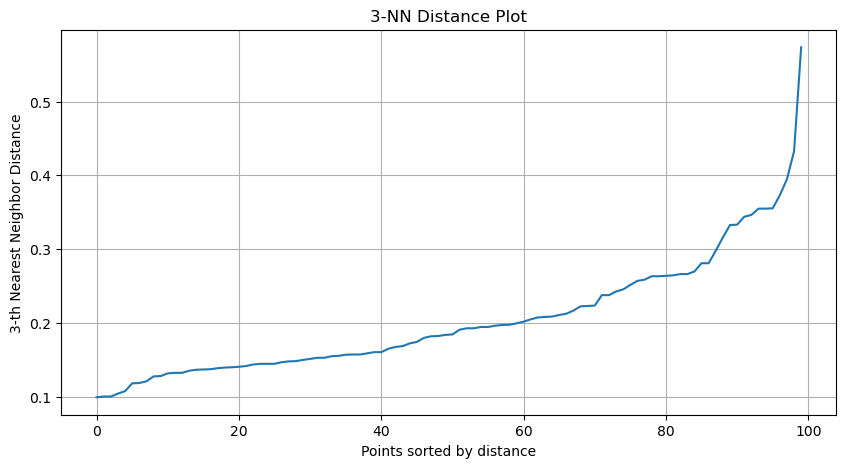

In [28]:
# For plotting purposes
import matplotlib.pyplot as plt

# Sample data
# Create number of rows and random x and y matrices
m = 100
# Use rand then multiple by 2 to make sure the samples values are between 0 and 2 this would make sure we simulate feature scaling
# Here we create 2 features
X1 = 2 * np.random.rand(m, 1)
X2 = 2 * np.random.rand(m, 1)
# Combine features to create X matrix
# We work only with x as y (label not exist)
X = np.column_stack((X1, X2))

# Test data with 2 rows
X_new = np.array([[1,2], [3,4], [4,3]])

# Get the best eps using Elblow method
print("The best epsilon...")

# Get DBSCAN object
# As min samples  = d + 1
dbscan_model = DBSCAN(min_samples=3)
dbscan_model.plot_k_distance(X)

In [29]:
# eps = 0.34 is the best
eps = 0.34

# min_samples conention is d + 1
min_samples = X.shape[1]+1

print(f'Model: DBSACN')
# Get DBSCAN object
dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_model.fit(X)
pred = dbscan_model.predict(X_new)
print(f'Predictions for {X_new.tolist()}: {pred}')
print(f'Evaluation score: {dbscan_model.silhouette_:.2f}')
print(f'Labels: \n{np.unique(dbscan_model.labels_)}')
print(f'Core points: \n{dbscan_model.core_indices}')
print('-'*40)

Model: DBSACN
Predictions for [[1, 2], [3, 4], [4, 3]]: [-1 -1 -1]
Evaluation score: nan
Labels: 
[-1  0]
Core points: 
[0]
----------------------------------------
